# December 2025 Status

(Most of these code chunks are me redoing some of the slides that I currently have in my slidedeck)

(see message thread with Evey on Jan 8 2026 for reference)

## Slide 3

=== FILE COVERAGE (pre-run) ===
Total JSON files found: 809
Session_outcomes files excluded: 8
Candidate session files scanned: 801

=== FILE COVERAGE (post-run) ===
Skip summary: {'load_fail': 0, 'no_utterances': 636, 'too_few_timestamps': 1, 'no_rows_after_filters': 8}
Sessions contributing at least 1 coded utterance: 156
Rows in df: 44370


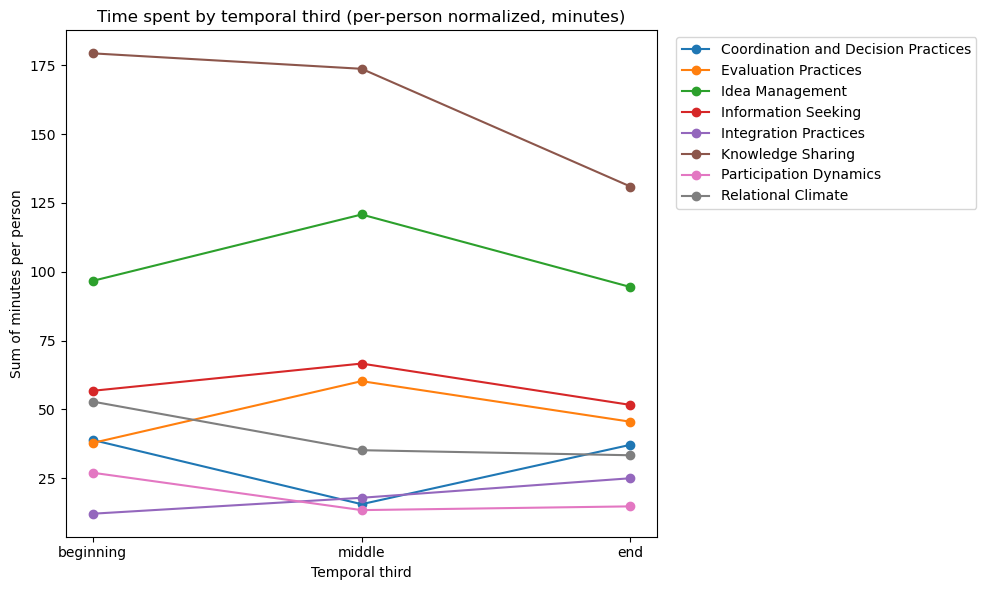

code,when,Coordination and Decision Practices,Evaluation Practices,Idea Management,Information Seeking,Integration Practices,Knowledge Sharing,Participation Dynamics,Relational Climate
0,beginning,38.892210,37.828009,96.710728,56.766349,12.109595,179.369813,26.991075,52.840434
1,middle,15.568522,60.268856,120.820733,66.658447,17.896984,173.755457,13.413868,35.182812
2,end,37.142128,45.529101,94.473047,51.638279,24.993976,130.974741,14.773891,33.347467


In [5]:
import os, json, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
BASE_DIR = "/Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/data"  # <-- change this
# For quick testing with your uploaded sample in this environment, uncomment:
# BASE_DIR = "/mnt/data"

TEMPORAL_ORDER = ["beginning", "middle", "end"]

# Multi-label handling:
# False = full duration credited to every code present (allows overlaps)
# True  = split duration evenly across all codes in that utterance (no within-utterance double count)
SPLIT_MULTI_LABEL_TIME = False

IGNORE_CODES = {"None", "Other", ""}

# If timestamps wrap (e.g., 09:39 -> 00:29), we "unwrap" them by adding an offset.
# This threshold (seconds) decides what counts as a wrap. 30s is conservative.
WRAP_THRESHOLD_SEC = 30


# =========================
# HELPERS
# =========================
def safe_load_json(path: str):
    with open(path, "r") as f:
        return json.load(f)

def extract_utterances(obj):
    """
    Tries common structures for your utterance-level session JSONs.
    Your example uses 'all_data'.
    """
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        for k in ["all_data", "utterances", "utterance_list", "data", "items"]:
            if k in obj and isinstance(obj[k], list):
                return obj[k]
    return None

def to_seconds(val):
    if val is None:
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    try:
        return float(str(val).strip())
    except:
        return np.nan

def parse_timestamp_to_sec(ts):
    """
    Accepts:
      - "MM:SS"
      - "HH:MM:SS"
    Returns seconds or NaN.
    """
    if ts is None:
        return np.nan
    s = str(ts).strip()
    if not s:
        return np.nan
    parts = s.split(":")
    try:
        parts = [int(p) for p in parts]
    except:
        return np.nan
    if len(parts) == 2:
        mm, ss = parts
        return mm * 60 + ss
    if len(parts) == 3:
        hh, mm, ss = parts
        return hh * 3600 + mm * 60 + ss
    return np.nan

def unwrap_time(seconds_list, wrap_threshold=WRAP_THRESHOLD_SEC):
    """
    Make a sequence monotonic by adding offsets when it appears to reset.
    If time goes backwards by more than threshold, treat as wrap/reset and add 3600s
    until monotonic.
    """
    out = []
    offset = 0.0
    prev = None
    for x in seconds_list:
        if not np.isfinite(x):
            out.append(np.nan)
            continue
        if prev is not None and np.isfinite(prev):
            if x < prev - wrap_threshold:
                while x + offset < prev:
                    offset += 3600.0
        gx = x + offset
        out.append(gx)
        prev = gx
    return out

def is_session_outcomes_file(path: str):
    return os.path.basename(path).endswith("_session_outcomes.json")


# =========================
# SCAN FILES + COVERAGE REPORTING
# =========================
json_paths = glob.glob(os.path.join(BASE_DIR, "**", "*.json"), recursive=True)
outcomes_paths = [p for p in json_paths if is_session_outcomes_file(p)]
session_paths = [p for p in json_paths if not is_session_outcomes_file(p)]

print("=== FILE COVERAGE (pre-run) ===")
print("Total JSON files found:", len(json_paths))
print("Session_outcomes files excluded:", len(outcomes_paths))
print("Candidate session files scanned:", len(session_paths))

skip = {
    "load_fail": 0,
    "no_utterances": 0,
    "too_few_timestamps": 0,
    "no_rows_after_filters": 0,
}

rows = []
processed_sessions = set()


for path in session_paths:
    try:
        obj = safe_load_json(path)
    except Exception:
        skip["load_fail"] += 1
        continue

    utterances = extract_utterances(obj)
    if not utterances:
        skip["no_utterances"] += 1
        continue

    # Use a unique-ish session id (path-relative) to avoid filename collisions across conferences
    session_id = os.path.relpath(path, BASE_DIR).replace(os.sep, "__").replace(".json", "")

    rows_before = len(rows)

    # Speakers for per-person normalization
    speakers = {(u.get("speaker") or "").strip() for u in utterances}
    speakers = {s for s in speakers if s}
    n_speakers = max(len(speakers), 1)

    # Build a per-utterance time axis (prefer start_time; else timestamp)
    t_raw = []
    for u in utterances:
        st = u.get("start_time", None)
        ts = u.get("timestamp", None)
        sec = parse_timestamp_to_sec(st) if st is not None else parse_timestamp_to_sec(ts)
        t_raw.append(sec)

    # Unwrap to global monotonic time within the session
    global_sec = unwrap_time(t_raw)

    # If all NaN, fall back to utterance index
    if np.all(~np.isfinite(global_sec)):
        global_sec = list(range(len(utterances)))

    # Assign temporal thirds from global_sec percentiles
    g = np.array(global_sec, dtype=float)
    if np.isfinite(g).sum() < 3:
        skip["too_few_timestamps"] += 1
        continue

    g_min, g_max = np.nanmin(g), np.nanmax(g)
    if g_max == g_min:
        g_norm = np.zeros_like(g)
    else:
        g_norm = (g - g_min) / (g_max - g_min)

    third_label = np.full(len(g_norm), None, dtype=object)
    third_label[(g_norm >= 0.0) & (g_norm < 1/3)] = "beginning"
    third_label[(g_norm >= 1/3) & (g_norm < 2/3)] = "middle"
    third_label[(g_norm >= 2/3) & (g_norm <= 1.0)] = "end"

    for u, when in zip(utterances, third_label):
        if when not in TEMPORAL_ORDER:
            continue

        dur_sec = to_seconds(u.get("speaking_duration"))
        if not np.isfinite(dur_sec) or dur_sec <= 0:
            continue

        ann = u.get("annotations", {})
        if not isinstance(ann, dict) or len(ann) == 0:
            continue

        codes = [c.strip() for c in ann.keys() if isinstance(c, str)]
        codes = [c for c in codes if c not in IGNORE_CODES]
        if not codes:
            continue

        if SPLIT_MULTI_LABEL_TIME:
            per_code_sec = dur_sec / len(codes)
        else:
            per_code_sec = dur_sec

        # Convert to minutes *after* multi-label logic
        per_code_min = per_code_sec / 60.0
        per_code_min_per_person = per_code_min / n_speakers

        for code in codes:
            rows.append({
                "session_id": session_id,
                "when": when,
                "code": code,
                "time_min_per_person": per_code_min_per_person,
            })

    if len(rows) == rows_before:
        skip["no_rows_after_filters"] += 1
    else:
        processed_sessions.add(session_id)


df = pd.DataFrame(rows)

print("\n=== FILE COVERAGE (post-run) ===")
print("Skip summary:", skip)
print("Sessions contributing at least 1 coded utterance:", len(processed_sessions))
print("Rows in df:", len(df))

if df.empty:
    raise ValueError(
        "No utterance annotations found. Likely BASE_DIR is pointing at the wrong folder, "
        "or your individual session files store utterances under a different key than expected."
    )

# =========================
# AGGREGATE + PLOT (MINUTES)
# =========================
agg = df.groupby(["code", "when"], as_index=False)["time_min_per_person"].sum()
agg["when"] = pd.Categorical(agg["when"], categories=TEMPORAL_ORDER, ordered=True)
agg = agg.sort_values(["code", "when"])

wide = agg.pivot(index="when", columns="code", values="time_min_per_person").fillna(0.0)
wide = wide.loc[TEMPORAL_ORDER]

plt.figure(figsize=(10, 6))
for code in wide.columns:
    plt.plot(wide.index.astype(str), wide[code].values, marker="o", label=code)

plt.title("Time spent by temporal third (per-person normalized, minutes)")
plt.xlabel("Temporal third")
plt.ylabel("Sum of minutes per person")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(wide.reset_index())

## Slide 4

=== OUTCOMES LABEL COVERAGE ===
Outcomes files found: 8
Outcomes files loaded: 8
Session keys with facilitator labels: 143

=== LABEL JOIN REPORT ===
Rows in df_indiv: 1576
Rows with facilitator label: 1451
Rows missing label (session not in outcomes): 125

Top missing session_keys:


session_key
2021_04_22_MND_S5     21
2021_05_21_ABI_S16    16
2021_04_23_MND_S14    12
2020_11_05_NES_S1     11
2020_11_06_NES_S4      9
2020_11_06_NES_S11     8
2020_11_06_NES_S2      8
2020_11_05_NES_S2      7
2020_11_05_NES_S5      7
2020_11_06_NES_S1      7
2020_11_06_NES_S12     7
2020_11_05_NES_S3      6
2020_11_06_NES_S7      6
Name: count, dtype: int64


=== Facilitator class balance (labeled rows) ===
is_facilitator
0    1246
1     205
Name: count, dtype: int64

=== Logistic regression results (odds ratios) ===


,feature,OR,CI_low,CI_high,p,sig_95CI
0,Idea Management,0.713648,0.531862,0.957567,2.450892e-02,True
1,Knowledge Sharing,0.720963,0.558765,0.930243,1.186612e-02,True
2,Integration Practices,0.993268,0.810994,1.216510,9.479362e-01,False
3,Evaluation Practices,1.159581,0.912562,1.473464,2.257513e-01,False
4,Relational Climate,1.272167,1.020190,1.586381,3.255808e-02,True
5,Information Seeking,1.640805,1.291216,2.085043,5.105780e-05,True
6,Participation Dynamics,2.049529,1.543840,2.720857,6.901680e-07,True
7,Coordination and Decision Practices,6.858216,4.735004,9.933490,2.269423e-24,True


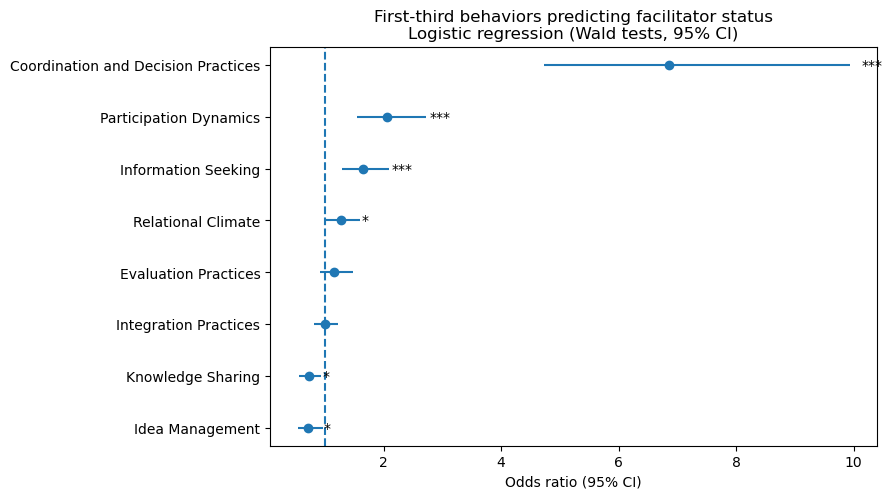

In [9]:
import os, json, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# -------------------------
# CONFIG (match your earlier settings)
# -------------------------
BASE_DIR = "/Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/data"  # same as before
OUTCOME = "is_facilitator"
STANDARDIZE = True  # OR per 1 SD increase

# df_indiv must already exist from your earlier chunk:
# columns: session_id, speaker, + code columns

# -------------------------
# Helpers
# -------------------------
def safe_load_json(path: str):
    with open(path, "r") as f:
        return json.load(f)

def normalize_name(s: str) -> str:
    """Normalize speaker names so outcomes & session speakers match."""
    if s is None:
        return ""
    s = str(s)
    # drop affiliations like "Marcel Schreier - UWisc Madison"
    s = re.split(r"\s+-\s+", s)[0]
    # collapse whitespace and strip
    s = re.sub(r"\s+", " ", s).strip()
    # lowercase for robust matching
    return s.lower()

def is_session_outcomes_file(path: str) -> bool:
    return os.path.basename(path).endswith("_session_outcomes.json")

def extract_session_key(session_id: str) -> str:
    """
    Your df_indiv session_id looks like:
      2020NES__session_data__2020_11_05_NES_S1
    We want the trailing key:
      2020_11_05_NES_S1
    """
    return str(session_id).split("__")[-1]

# -------------------------
# Build: session_key -> set(facilitators)
# -------------------------
outcomes_paths = glob.glob(os.path.join(BASE_DIR, "**", "*_session_outcomes.json"), recursive=True)

sessionkey_to_facilitators = {}
outcomes_loaded = 0

for p in outcomes_paths:
    try:
        obj = safe_load_json(p)
    except Exception:
        continue

    # outcomes file structure: dict keyed by session_key -> dict with 'facilitators'
    if not isinstance(obj, dict):
        continue

    outcomes_loaded += 1

    for session_key, entry in obj.items():
        if not isinstance(entry, dict):
            continue

        facs = entry.get("facilitators", None)
        if facs is None:
            continue

        if isinstance(facs, str):
            fac_list = [facs]
        elif isinstance(facs, list):
            fac_list = facs
        else:
            continue

        fac_norm = {normalize_name(x) for x in fac_list if normalize_name(x)}
        if not fac_norm:
            continue

        sessionkey_to_facilitators.setdefault(session_key, set()).update(fac_norm)

print("=== OUTCOMES LABEL COVERAGE ===")
print("Outcomes files found:", len(outcomes_paths))
print("Outcomes files loaded:", outcomes_loaded)
print("Session keys with facilitator labels:", len(sessionkey_to_facilitators))

# -------------------------
# Attach labels to df_indiv
# -------------------------
df_indiv = df_indiv.copy()
df_indiv["session_key"] = df_indiv["session_id"].apply(extract_session_key)
df_indiv["speaker_norm"] = df_indiv["speaker"].apply(normalize_name)

def label_facilitator(row):
    facs = sessionkey_to_facilitators.get(row["session_key"], None)
    if facs is None:
        return np.nan  # unknown label for this session
    return 1 if row["speaker_norm"] in facs else 0

df_indiv[OUTCOME] = df_indiv.apply(label_facilitator, axis=1)

# Report label join success
n_total = len(df_indiv)
n_labeled = df_indiv[OUTCOME].notna().sum()
n_missing = n_total - n_labeled

print("\n=== LABEL JOIN REPORT ===")
print("Rows in df_indiv:", n_total)
print("Rows with facilitator label:", n_labeled)
print("Rows missing label (session not in outcomes):", n_missing)

# If you want, see which sessions are missing:
if n_missing > 0:
    missing_sessions = df_indiv.loc[df_indiv[OUTCOME].isna(), "session_key"].value_counts().head(20)
    print("\nTop missing session_keys:")
    display(missing_sessions)

# Drop unlabeled rows for modeling
df_model = df_indiv.dropna(subset=[OUTCOME]).copy()
df_model[OUTCOME] = df_model[OUTCOME].astype(int)

print("\n=== Facilitator class balance (labeled rows) ===")
print(df_model[OUTCOME].value_counts())

# -------------------------
# Logistic regression
# -------------------------
feature_cols = [c for c in df_model.columns if c not in ["session_id", "speaker", "session_key", "speaker_norm", OUTCOME]]

X = df_model[feature_cols].astype(float)
y = df_model[OUTCOME].astype(int)

if STANDARDIZE:
    X = (X - X.mean()) / (X.std(ddof=0).replace(0, np.nan))
    X = X.fillna(0.0)

X = sm.add_constant(X)

model = sm.Logit(y, X)
res = model.fit(disp=False)

beta = res.params
se = res.bse
pvals = res.pvalues

OR = np.exp(beta)
CI_low = np.exp(beta - 1.96 * se)
CI_high = np.exp(beta + 1.96 * se)

out = (
    pd.DataFrame({
        "feature": beta.index,
        "beta": beta.values,
        "se": se.values,
        "p": pvals.values,
        "OR": OR.values,
        "CI_low": CI_low.values,
        "CI_high": CI_high.values,
    })
    .query("feature != 'const'")
    .sort_values("OR", ascending=True)
    .reset_index(drop=True)
)

out["sig_95CI"] = ~((out["CI_low"] <= 1.0) & (out["CI_high"] >= 1.0))

print("\n=== Logistic regression results (odds ratios) ===")
display(out[["feature", "OR", "CI_low", "CI_high", "p", "sig_95CI"]])

# -------------------------
# Forest plot
# -------------------------
fig_h = max(4, 0.45 * len(out) + 1.5)
plt.figure(figsize=(9, fig_h))

ypos = np.arange(len(out))
plt.hlines(y=ypos, xmin=out["CI_low"], xmax=out["CI_high"])
plt.plot(out["OR"], ypos, "o")
plt.axvline(1.0, linestyle="--")

plt.yticks(ypos, out["feature"])
plt.xlabel("Odds ratio (95% CI)")
plt.title("First-third behaviors predicting facilitator status\nLogistic regression (Wald tests, 95% CI)")

for i, row in out.iterrows():
    if row["p"] < 0.001:
        star = "***"
    elif row["p"] < 0.01:
        star = "**"
    elif row["p"] < 0.05:
        star = "*"
    else:
        star = ""
    if star:
        plt.text(row["CI_high"] * 1.02, i, star, va="center")

plt.tight_layout()
plt.show()

In [10]:
# assuming you already have:
#   res = statsmodels Logit (or GLM Binomial) fitted result

import pandas as pd
import numpy as np

summary = pd.DataFrame({
    "coef": res.params,
    "se": res.bse,
    "z": res.tvalues,          # Wald z-stat
    "p": res.pvalues,          # Wald p-value
    "OR": np.exp(res.params),
    "CI_low": np.exp(res.conf_int()[0]),
    "CI_high": np.exp(res.conf_int()[1]),
})

# drop intercept if you want
summary = summary.drop(index=[i for i in summary.index if "Intercept" in str(i) or "const" in str(i)], errors="ignore")

summary = summary.sort_values("p")
display(summary)

,coef,se,z,p,OR,CI_low,CI_high
Coordination and Decision Practices,1.925447,0.189013,10.186875,2.269423e-24,6.858216,4.735037,9.933423
Participation Dynamics,0.717610,0.144560,4.964110,6.901680e-07,2.049529,1.543848,2.720843
Information Seeking,0.495187,0.122246,4.050731,5.105780e-05,1.640805,1.291221,2.085034
Knowledge Sharing,-0.327168,0.130030,-2.516101,1.186612e-02,0.720963,0.558768,0.930238
Idea Management,-0.337365,0.150003,-2.249056,2.450892e-02,0.713648,0.531865,0.957562
Relational Climate,0.240722,0.112619,2.137491,3.255808e-02,1.272167,1.020194,1.586374
Evaluation Practices,0.148058,0.122223,1.211376,2.257513e-01,1.159581,0.912566,1.473457
Integration Practices,-0.006754,0.103439,-0.065299,9.479362e-01,0.993268,0.810997,1.216505


## Slide 5

=== Person-session feature table ===
Rows (person×session): 1576
Num behavior features: 8

=== Outcome counts (on_team_any) ===
on_team_any
1    985
0    591
Name: count, dtype: int64
Positive rate: 0.6250

=== Model check ===
Model: sklearn LogisticRegression
Penalty: l2 (ridge/L2)
C: 1.0
Class weight: balanced
Interpretation: OR per 1 SD increase in feature (because of StandardScaler)

=== Ridge logistic results (PERSON-LEVEL team formation; per 1 SD; bootstrap 95% CI) ===


,OR,CI_low,CI_high,CI_excludes_1
Idea Management,1.195972,0.888443,1.503756,False
Knowledge Sharing,1.152369,0.926334,1.745858,False
Evaluation Practices,1.134119,0.942470,1.369306,False
Relational Climate,1.133968,0.960018,1.363123,False
Integration Practices,1.118304,0.952445,1.341751,False
Information Seeking,1.105996,0.930364,1.352491,False
Participation Dynamics,0.603218,0.401229,0.784283,True
Coordination and Decision Practices,0.299569,0.190824,0.421789,True



=== Predictors whose bootstrap CI excludes OR=1 ===


,OR,CI_low,CI_high,CI_excludes_1
Participation Dynamics,0.603218,0.401229,0.784283,True
Coordination and Decision Practices,0.299569,0.190824,0.421789,True


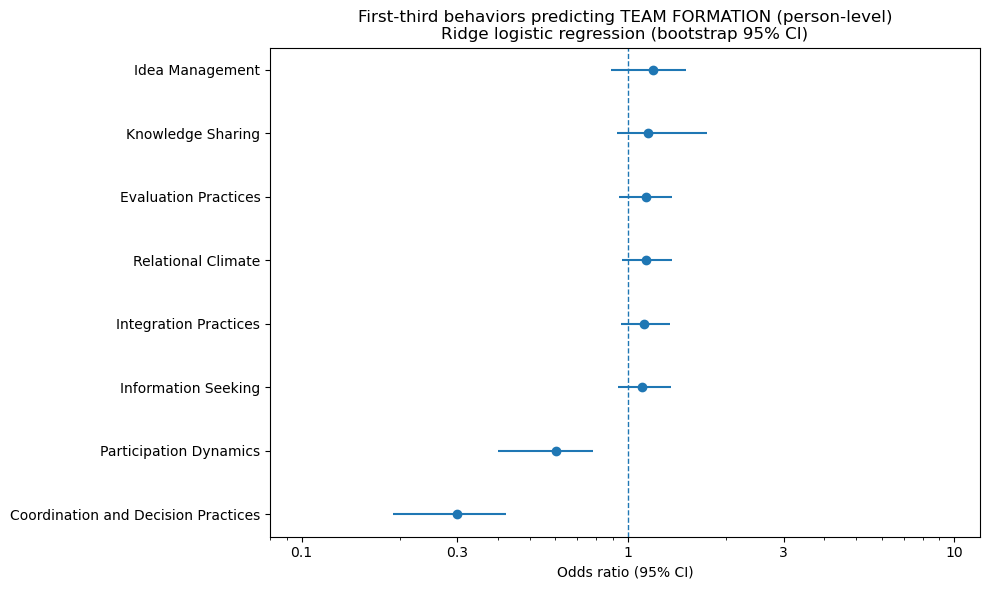

In [29]:
# =========================
# TEAM FORMATION (PERSON-LEVEL):
# Ridge logistic + bootstrap 95% CI + forest plot (fixed x-ticks)
#
# Assumes you already have:
#   - df : utterance-level rows with columns: session_id, speaker, when, code, time_min_per_person (from your scan)
#   - PERSON_TO_TEAM : dict mapping person name -> team id(s) / structure (from your label loading)
#
# Outcome:
#   on_team_any = 1 if speaker maps to >=1 team id in PERSON_TO_TEAM, else 0
#
# Features:
#   First-third ("beginning") behavior totals per person per session (minutes)
#   (Uses df["time_min_per_person"] which is already normalized; if you want RAW minutes instead,
#    rebuild df with per_code_min_per_person = per_code_sec/60.0 (no / n_speakers).)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from matplotlib.ticker import FixedLocator, FuncFormatter

# ---------- helpers (same logic as your funded pipeline) ----------
def normalize_team_ids(team_val):
    out = []
    if team_val is None:
        return out
    if isinstance(team_val, dict):
        if "team_id" in team_val:
            tid = team_val.get("team_id")
            if tid is not None:
                out.append(tid)
        else:
            for v in team_val.values():
                out.extend(normalize_team_ids(v))
        return out
    if isinstance(team_val, list):
        for v in team_val:
            out.extend(normalize_team_ids(v))
        return out
    out.append(team_val)
    return out

def make_hashable_team_id(tid):
    if tid is None:
        return None
    if isinstance(tid, (str, int)):
        s = str(tid).strip()
        return s if s else None
    try:
        s = str(tid).strip()
        return s if s else None
    except Exception:
        return None

def person_on_team_any(person_name, PERSON_TO_TEAM):
    team_val = PERSON_TO_TEAM.get(person_name, None)
    team_ids = [make_hashable_team_id(t) for t in normalize_team_ids(team_val)]
    team_ids = [t for t in team_ids if t]
    return int(len(team_ids) > 0)

# ---------- 1) build person × session features (FIRST THIRD ONLY) ----------
df_first = df[df["when"] == "beginning"].copy()

# drop missing speaker names
df_first["speaker"] = df_first["speaker"].fillna("").astype(str).str.strip()
df_first = df_first[df_first["speaker"] != ""].copy()

# aggregate minutes by (session, person, code)
df_ps = (
    df_first.groupby(["session_id", "speaker", "code"], as_index=False)["time_min_per_person"]
    .sum()
)

# pivot to wide features
df_feat = (
    df_ps.pivot_table(index=["session_id", "speaker"], columns="code", values="time_min_per_person", fill_value=0.0)
    .reset_index()
)

print("=== Person-session feature table ===")
print("Rows (person×session):", len(df_feat))
print("Num behavior features:", df_feat.shape[1] - 2)

# ---------- 2) add outcome: on_team_any ----------
df_feat["on_team_any"] = df_feat["speaker"].apply(lambda p: person_on_team_any(p, PERSON_TO_TEAM)).astype(int)

vc = df_feat["on_team_any"].value_counts(dropna=False)
pos_rate = df_feat["on_team_any"].mean()

print("\n=== Outcome counts (on_team_any) ===")
print(vc)
print(f"Positive rate: {pos_rate:.4f}")

if vc.min() < 10:
    print("WARNING: Severe class imbalance at person-level too. Expect wide CIs.\n")

if df_feat["on_team_any"].nunique() < 2:
    raise ValueError(
        "Degenerate outcome at person-level too (only one class). "
        "That means everyone in these sessions is mapped to a team (or no one is). "
        "You need a different label source or a different cohort slice."
    )

# ---------- 3) build X/y ----------
DROP_COLS = {"session_id", "speaker", "on_team_any"}
FEATURES = [c for c in df_feat.columns if c not in DROP_COLS]

X = df_feat[FEATURES].copy()
y = df_feat["on_team_any"].astype(int).values

# drop zero-variance features
zero_var_cols = [c for c in FEATURES if np.isclose(X[c].var(ddof=0), 0.0)]
if zero_var_cols:
    print("Dropping zero-variance features:", zero_var_cols)
    X = X.drop(columns=zero_var_cols)
    FEATURES = [c for c in FEATURES if c not in zero_var_cols]

X_mat = X.values

# ---------- 4) fit ridge logistic ----------
C_VAL = 1.0
clf = make_pipeline(
    StandardScaler(with_mean=True, with_std=True),
    LogisticRegression(
        penalty="l2",
        C=C_VAL,
        solver="lbfgs",
        max_iter=5000,
        class_weight="balanced",
        random_state=0,
    )
)
clf.fit(X_mat, y)

lr = clf.named_steps["logisticregression"]
coef_sd = lr.coef_.ravel()              # per 1 SD increase (because StandardScaler)
OR_point = np.exp(coef_sd)

print("\n=== Model check ===")
print("Model: sklearn LogisticRegression")
print("Penalty: l2 (ridge/L2)")
print("C:", C_VAL)
print("Class weight: balanced")
print("Interpretation: OR per 1 SD increase in feature (because of StandardScaler)")

# ---------- 5) bootstrap 95% CI (stratified) ----------
rng = np.random.default_rng(0)
n_boot = 1000

idx_pos = np.where(y == 1)[0]
idx_neg = np.where(y == 0)[0]
n_pos, n_neg = len(idx_pos), len(idx_neg)

boot_or = np.zeros((n_boot, len(FEATURES)), dtype=float)

for b in range(n_boot):
    samp_pos = rng.choice(idx_pos, size=n_pos, replace=True)
    samp_neg = rng.choice(idx_neg, size=n_neg, replace=True)
    samp_idx = np.concatenate([samp_pos, samp_neg])

    Xb = X_mat[samp_idx]
    yb = y[samp_idx]

    cb = make_pipeline(
        StandardScaler(with_mean=True, with_std=True),
        LogisticRegression(
            penalty="l2",
            C=C_VAL,
            solver="lbfgs",
            max_iter=5000,
            class_weight="balanced",
            random_state=0,
        )
    )
    cb.fit(Xb, yb)
    boot_or[b, :] = np.exp(cb.named_steps["logisticregression"].coef_.ravel())

CI_low = np.quantile(boot_or, 0.025, axis=0)
CI_high = np.quantile(boot_or, 0.975, axis=0)

out = pd.DataFrame({"OR": OR_point, "CI_low": CI_low, "CI_high": CI_high}, index=FEATURES)
out["CI_excludes_1"] = (out["CI_low"] > 1.0) | (out["CI_high"] < 1.0)
out_sorted = out.sort_values("OR", ascending=False)

print("\n=== Ridge logistic results (PERSON-LEVEL team formation; per 1 SD; bootstrap 95% CI) ===")
display(out_sorted)

print("\n=== Predictors whose bootstrap CI excludes OR=1 ===")
display(out_sorted[out_sorted["CI_excludes_1"]][["OR", "CI_low", "CI_high", "CI_excludes_1"]])

# ---------- 6) forest plot with fixed ticks (slide-consistent) ----------
plot_df = out_sorted.sort_values("OR").copy()
eps = 1e-12
plot_df[["CI_low", "OR", "CI_high"]] = plot_df[["CI_low", "OR", "CI_high"]].clip(lower=eps)

fig, ax = plt.subplots(figsize=(10, 6))
ypos = np.arange(len(plot_df))

ax.hlines(y=ypos, xmin=plot_df["CI_low"], xmax=plot_df["CI_high"])
ax.plot(plot_df["OR"], ypos, "o")
ax.axvline(1.0, linestyle="--", linewidth=1)

ax.set_xscale("log")
tick_vals = [0.1, 0.3, 1, 3, 10]
ax.xaxis.set_major_locator(FixedLocator(tick_vals))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}"))
ax.set_xlim(0.08, 12)

ax.set_yticks(ypos)
ax.set_yticklabels(plot_df.index)

ax.set_xlabel("Odds ratio (95% CI)")
ax.set_title(
    "First-third behaviors predicting TEAM FORMATION (person-level)\n"
    "Ridge logistic regression (bootstrap 95% CI)"
)

plt.tight_layout()
plt.show()

=== Using dataframe: df_feat ===
Shape: (1576, 11)

=== Outcome counts (on_team_any) ===
0    591
1    985
Name: count, dtype: int64
Positive rate: 0.6250

=== Model check ===
Model: sklearn LogisticRegression
Penalty: l2 (ridge/L2)
C: 1.0
Class weight: balanced
Interpretation: OR per 1 SD increase in feature (because of StandardScaler)

=== Ridge logistic results (PERSON-LEVEL on_team_any; per 1 SD; bootstrap 95% CI) ===


,OR,CI_low,CI_high,CI_excludes_1
Idea Management,1.195972,0.888443,1.503756,False
Knowledge Sharing,1.152369,0.926334,1.745858,False
Evaluation Practices,1.134119,0.942470,1.369306,False
Relational Climate,1.133968,0.960018,1.363123,False
Integration Practices,1.118304,0.952445,1.341751,False
Information Seeking,1.105996,0.930364,1.352491,False
Participation Dynamics,0.603218,0.401229,0.784283,True
Coordination and Decision Practices,0.299569,0.190824,0.421789,True



=== Predictors whose bootstrap CI excludes OR=1 ===


,OR,CI_low,CI_high,CI_excludes_1
Participation Dynamics,0.603218,0.401229,0.784283,True
Coordination and Decision Practices,0.299569,0.190824,0.421789,True


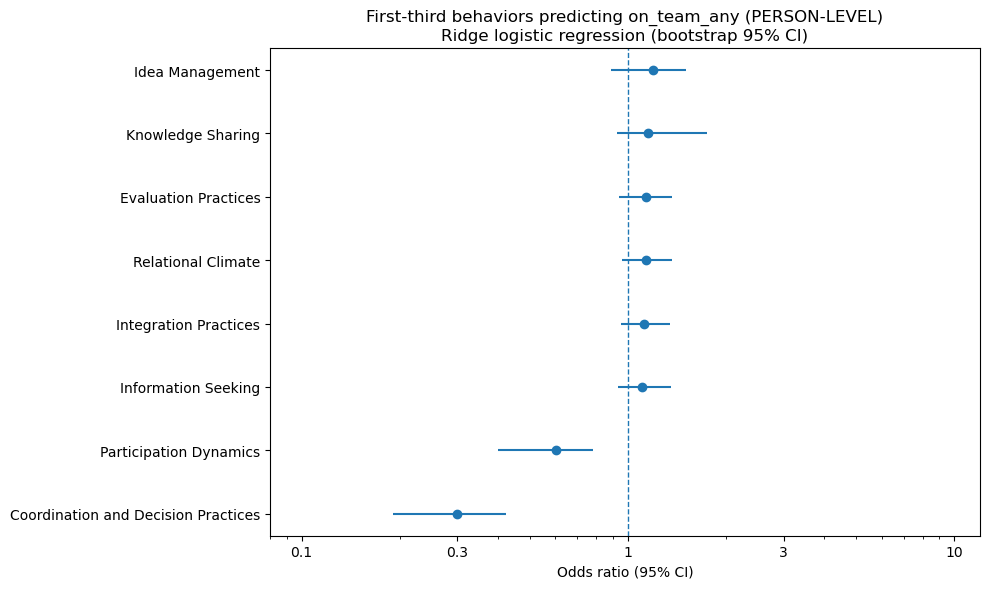


=== P-values (reference only): plain, unpenalized Logit Wald tests ===


,OR,CI_low,CI_high,p
Coordination and Decision Practices,0.293248,0.217167,0.395981,1.110223e-15
Participation Dynamics,0.613989,0.487237,0.773716,3.554869e-05
Idea Management,1.207621,0.988211,1.475746,6.517236e-02
Knowledge Sharing,1.224467,0.980597,1.528986,7.392264e-02
Integration Practices,1.118184,0.963302,1.297969,1.419713e-01
Evaluation Practices,1.123359,0.956503,1.319322,1.562152e-01
Relational Climate,1.112088,0.952045,1.299036,1.802091e-01
Information Seeking,1.097067,0.934867,1.287408,2.564149e-01


In [35]:
# =========================
# PERSON-LEVEL TEAM FORMATION (df_feat)
# Ridge logistic + stratified bootstrap 95% OR CIs + forest plot (fixed x-ticks)
# PLUS: Plain (unpenalized) logistic Wald p-values for reference (statsmodels)
# Outcome: on_team_any
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from matplotlib.ticker import FixedLocator, FuncFormatter

# -------------------------
# 0) CONFIG
# -------------------------
DF_NAME = "df_feat"          # <- your confirmed dataframe
OUTCOME_COL = "on_team_any"  # <- your confirmed outcome
ID_COLS = {"session_id", "speaker"}  # non-feature identifiers

C_VAL = 1.0
N_BOOT = 1000
RNG_SEED = 0

# -------------------------
# 1) LOAD + SANITY CHECKS
# -------------------------
df = globals()[DF_NAME].copy()

if OUTCOME_COL not in df.columns:
    raise ValueError(f"Outcome column '{OUTCOME_COL}' not in {DF_NAME}. Columns:\n{list(df.columns)}")

y = df[OUTCOME_COL].astype(int).values
vc = pd.Series(y).value_counts().sort_index()
pos_rate = float(np.mean(y))

print(f"=== Using dataframe: {DF_NAME} ===")
print(f"Shape: {df.shape}")
print(f"\n=== Outcome counts ({OUTCOME_COL}) ===")
print(vc)
print(f"Positive rate: {pos_rate:.4f}\n")

if vc.min() < 10:
    print("WARNING: Severe class imbalance. Wald SEs/p-values can be unreliable (separation risk).\n")

if len(np.unique(y)) < 2:
    raise ValueError("Degenerate outcome: only one class present. Cannot fit logistic regression.")

# -------------------------
# 2) BUILD FEATURES MATRIX
# -------------------------
DROP_COLS = set(ID_COLS) | {OUTCOME_COL}
FEATURES = [c for c in df.columns if c not in DROP_COLS]

X = df[FEATURES].copy()

# Drop zero-variance features
zero_var_cols = [c for c in FEATURES if np.isclose(X[c].var(ddof=0), 0.0)]
if zero_var_cols:
    print("Dropping zero-variance features:", zero_var_cols)
    X = X.drop(columns=zero_var_cols)
    FEATURES = [c for c in FEATURES if c not in zero_var_cols]

X_mat = X.values

# -------------------------
# 3) FIT RIDGE LOGISTIC (SKLEARN)
# -------------------------
model = make_pipeline(
    StandardScaler(with_mean=True, with_std=True),
    LogisticRegression(
        penalty="l2",
        C=C_VAL,
        solver="lbfgs",
        max_iter=5000,
        class_weight="balanced",
        random_state=RNG_SEED,
    )
)
model.fit(X_mat, y)

lr = model.named_steps["logisticregression"]
coef_sd = lr.coef_.ravel()          # per 1 SD increase (StandardScaler)
OR_point = np.exp(coef_sd)

print("=== Model check ===")
print("Model: sklearn LogisticRegression")
print("Penalty: l2 (ridge/L2)")
print("C:", C_VAL)
print("Class weight: balanced")
print("Interpretation: OR per 1 SD increase in feature (because of StandardScaler)\n")

# -------------------------
# 4) STRATIFIED BOOTSTRAP 95% CI FOR ORs (RIDGE MODEL)
# -------------------------
rng = np.random.default_rng(RNG_SEED)

idx_pos = np.where(y == 1)[0]
idx_neg = np.where(y == 0)[0]
n_pos, n_neg = len(idx_pos), len(idx_neg)

boot_or = np.zeros((N_BOOT, len(FEATURES)), dtype=float)

for b in range(N_BOOT):
    samp_pos = rng.choice(idx_pos, size=n_pos, replace=True)
    samp_neg = rng.choice(idx_neg, size=n_neg, replace=True)
    samp_idx = np.concatenate([samp_pos, samp_neg])

    Xb = X_mat[samp_idx]
    yb = y[samp_idx]

    mb = make_pipeline(
        StandardScaler(with_mean=True, with_std=True),
        LogisticRegression(
            penalty="l2",
            C=C_VAL,
            solver="lbfgs",
            max_iter=5000,
            class_weight="balanced",
            random_state=RNG_SEED,
        )
    )
    mb.fit(Xb, yb)
    boot_or[b, :] = np.exp(mb.named_steps["logisticregression"].coef_.ravel())

CI_low = np.quantile(boot_or, 0.025, axis=0)
CI_high = np.quantile(boot_or, 0.975, axis=0)

out = pd.DataFrame({"OR": OR_point, "CI_low": CI_low, "CI_high": CI_high}, index=FEATURES)
out["CI_excludes_1"] = (out["CI_low"] > 1.0) | (out["CI_high"] < 1.0)
out_sorted = out.sort_values("OR", ascending=False)

print(f"=== Ridge logistic results (PERSON-LEVEL {OUTCOME_COL}; per 1 SD; bootstrap 95% CI) ===")
display(out_sorted)

print("\n=== Predictors whose bootstrap CI excludes OR=1 ===")
display(out_sorted[out_sorted["CI_excludes_1"]])

# -------------------------
# 5) FOREST PLOT (LOG SCALE + FIXED SLIDE TICKS)
# -------------------------
plot_df = out_sorted.sort_values("OR").copy()
eps = 1e-12
plot_df[["CI_low", "OR", "CI_high"]] = plot_df[["CI_low", "OR", "CI_high"]].clip(lower=eps)

fig, ax = plt.subplots(figsize=(10, 6))
ypos = np.arange(len(plot_df))

ax.hlines(y=ypos, xmin=plot_df["CI_low"], xmax=plot_df["CI_high"])
ax.plot(plot_df["OR"], ypos, "o")
ax.axvline(1.0, linestyle="--", linewidth=1)

ax.set_xscale("log")
tick_vals = [0.1, 0.3, 1, 3, 10]
ax.xaxis.set_major_locator(FixedLocator(tick_vals))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}"))
ax.set_xlim(0.08, 12)

ax.set_yticks(ypos)
ax.set_yticklabels(plot_df.index)

ax.set_xlabel("Odds ratio (95% CI)")
ax.set_title(
    f"First-third behaviors predicting {OUTCOME_COL} (PERSON-LEVEL)\n"
    "Ridge logistic regression (bootstrap 95% CI)"
)

plt.tight_layout()
plt.show()

# -------------------------
# 6) OPTIONAL: P-VALUES (REFERENCE ONLY)
# Plain, unpenalized logistic regression (statsmodels) on the SAME X/y
# Note: uses standard (Wald) z-tests. Not the ridge model.
# -------------------------
try:
    import statsmodels.api as sm
    from scipy.stats import norm

    # Standardize X for comparability with ridge "per 1 SD" interpretation
    X_std = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0)
    X_std = X_std.replace([np.inf, -np.inf], np.nan).dropna(axis=1)
    used_cols = list(X_std.columns)

    X_sm = sm.add_constant(X_std, has_constant="add")

    # Fit plain logit
    sm_model = sm.Logit(y, X_sm)
    sm_res = sm_model.fit(disp=False, maxiter=200)

    coef = sm_res.params
    se = sm_res.bse
    z = coef / se
    pvals = 2 * (1 - norm.cdf(np.abs(z)))

    wald = pd.DataFrame(
        {
            "coef": coef,
            "se": se,
            "z": z,
            "p": pvals,
            "OR": np.exp(coef),
            "CI_low": np.exp(coef - 1.96 * se),
            "CI_high": np.exp(coef + 1.96 * se),
        }
    )

    # Drop intercept and format nicely
    wald = wald.drop(index="const", errors="ignore")
    wald = wald.loc[used_cols]  # keep same order as standardized columns

    wald_sorted = wald.sort_values("p")
    print("\n=== P-values (reference only): plain, unpenalized Logit Wald tests ===")
    display(wald_sorted[["OR", "CI_low", "CI_high", "p"]])

except Exception as e:
    print("\nStatsmodels p-value check failed (can happen with separation/collinearity):", repr(e))

## Slide 6

=== Outcome counts (funded_any) ===
1    151
0      4
Name: count, dtype: int64
Positive rate: 0.9741935483870968

=== Ridge logistic results (per 1 SD increase; bootstrap 95% CI) ===


,OR,CI_low,CI_high,CI_excludes_1
Information Seeking,2.924609,0.456248,28.667391,False
Knowledge Sharing,2.285290,0.522353,6.316278,False
Idea Management,1.809595,0.358200,9.798058,False
Integration Practices,1.801951,0.865752,8.560788,False
Participation Dynamics,1.576483,0.194699,12.576898,False
Coordination and Decision Practices,0.635254,0.268076,2.356373,False
Evaluation Practices,0.148094,0.045456,0.688339,True
Relational Climate,0.146218,0.064448,1.464735,False



=== Predictors whose bootstrap CI excludes OR=1 (stronger evidence) ===


,OR,CI_low,CI_high,CI_excludes_1
Evaluation Practices,0.148094,0.045456,0.688339,True


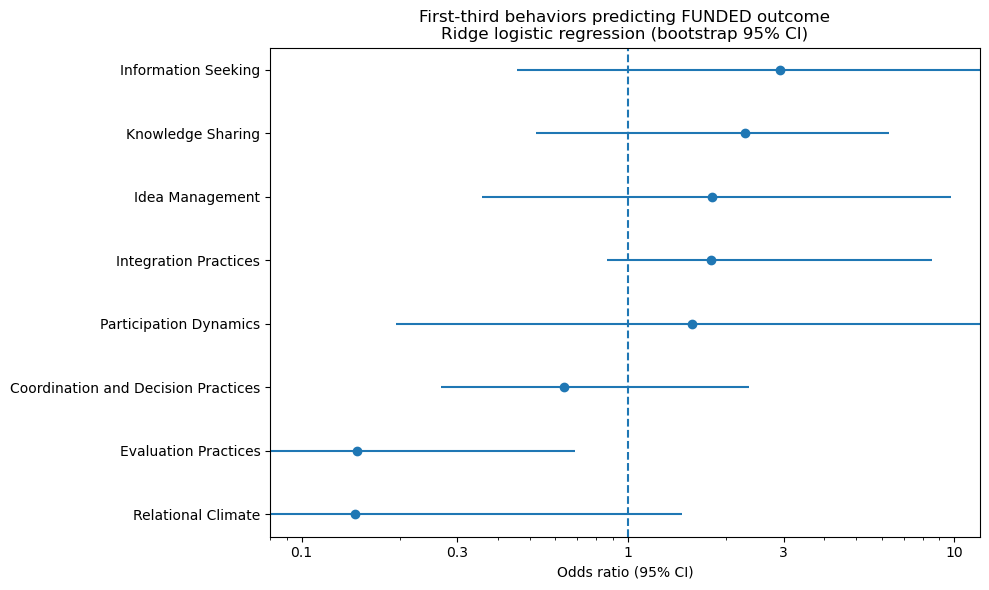


MODEL SUMMARY:
• Model: Ridge-regularized logistic regression (L2)
• Outcome: funded_any (binary)
• Predictors: first-third meeting behaviors
• Scaling: Standardized (ORs are per 1 SD increase)
• Inference: Bootstrap 95% confidence intervals
• Rationale: Extreme class imbalance makes Wald p-values unstable



In [25]:
# ============================================================
# Ridge-regularized logistic regression + bootstrap OR CIs
# Canonical verification cell for slide + speaker notes
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from matplotlib.ticker import FixedLocator, FuncFormatter

# ----------------------------
# 1. Build X / y
# ----------------------------
FEATURES = [c for c in df_labeled.columns
            if c not in {"session_id", "session_key", "funded_any"}]

X = df_labeled[FEATURES].values
y = df_labeled["funded_any"].astype(int).values

print("=== Outcome counts (funded_any) ===")
print(pd.Series(y).value_counts())
print("Positive rate:", y.mean())
print("WARNING: Severe class imbalance. Wald SEs/p-values can be unreliable.\n")

# ----------------------------
# 2. Fit ridge logistic model
# ----------------------------
C_VAL = 1.0  # ridge strength

ridge_clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        class_weight="balanced",
        C=C_VAL,
        max_iter=5000,
        random_state=0,
    )
)

ridge_clf.fit(X, y)

coef_sd = ridge_clf.named_steps["logisticregression"].coef_.ravel()
OR_point = np.exp(coef_sd)

# ----------------------------
# 3. Bootstrap 95% CIs (stratified)
# ----------------------------
rng = np.random.default_rng(0)
n_boot = 1000

idx_pos = np.where(y == 1)[0]
idx_neg = np.where(y == 0)[0]

boot_or = np.zeros((n_boot, len(FEATURES)))

for b in range(n_boot):
    samp_idx = np.concatenate([
        rng.choice(idx_pos, size=len(idx_pos), replace=True),
        rng.choice(idx_neg, size=len(idx_neg), replace=True),
    ])

    Xb, yb = X[samp_idx], y[samp_idx]

    cb = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            class_weight="balanced",
            C=C_VAL,
            max_iter=5000,
        )
    )
    cb.fit(Xb, yb)
    boot_or[b] = np.exp(cb.named_steps["logisticregression"].coef_.ravel())

CI_low = np.quantile(boot_or, 0.025, axis=0)
CI_high = np.quantile(boot_or, 0.975, axis=0)

results = pd.DataFrame(
    {
        "OR": OR_point,
        "CI_low": CI_low,
        "CI_high": CI_high,
        "CI_excludes_1": (CI_low > 1) | (CI_high < 1),
    },
    index=FEATURES,
).sort_values("OR", ascending=False)

print("=== Ridge logistic results (per 1 SD increase; bootstrap 95% CI) ===")
display(results)

print("\n=== Predictors whose bootstrap CI excludes OR=1 (stronger evidence) ===")
display(results[results["CI_excludes_1"]])

# ----------------------------
# 4. Forest plot (match earlier slide ticks)
# ----------------------------
plot_df = results.sort_values("OR").copy()
eps = 1e-12
plot_df[["OR", "CI_low", "CI_high"]] = plot_df[["OR", "CI_low", "CI_high"]].clip(lower=eps)

fig, ax = plt.subplots(figsize=(10, 6))
ypos = np.arange(len(plot_df))

ax.hlines(y=ypos, xmin=plot_df["CI_low"], xmax=plot_df["CI_high"])
ax.plot(plot_df["OR"], ypos, "o")
ax.axvline(1.0, linestyle="--")

ax.set_xscale("log")
ax.set_xlim(0.08, 12)

tick_vals = [0.1, 0.3, 1, 3, 10]
ax.xaxis.set_major_locator(FixedLocator(tick_vals))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}"))

ax.set_yticks(ypos)
ax.set_yticklabels(plot_df.index)
ax.set_xlabel("Odds ratio (95% CI)")
ax.set_title(
    "First-third behaviors predicting FUNDED outcome\n"
    "Ridge logistic regression (bootstrap 95% CI)"
)

plt.tight_layout()
plt.show()

# ----------------------------
# 5. Explicit model statement (for speaker notes)
# ----------------------------
print("""
MODEL SUMMARY:
• Model: Ridge-regularized logistic regression (L2)
• Outcome: funded_any (binary)
• Predictors: first-third meeting behaviors
• Scaling: Standardized (ORs are per 1 SD increase)
• Inference: Bootstrap 95% confidence intervals
• Rationale: Extreme class imbalance makes Wald p-values unstable
""")

In [37]:
# ============================================================
# REFERENCE ONLY: Plain logistic regression Wald p-values
# Fixes index/row alignment + missingness
# (NOT the ridge model; unstable under imbalance)
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import norm

# 1) Build a single aligned table (X + y), then drop missing rows ONCE
X_df = df_labeled[FEATURES].copy()
y_s = df_labeled["funded_any"].astype(int).copy()   # pandas Series with index

# Standardize X (per 1 SD increase)
X_std = (X_df - X_df.mean(axis=0)) / X_df.std(axis=0, ddof=0)
X_std = X_std.replace([np.inf, -np.inf], np.nan)

# Combine and drop rows with any missing values (this is the key fix)
dat = pd.concat([y_s.rename("y"), X_std], axis=1).dropna(axis=0).copy()

y_aligned = dat["y"].astype(int)
X_aligned = dat.drop(columns=["y"])

# Optional: drop any columns that are still all-NaN or constant after alignment
X_aligned = X_aligned.dropna(axis=1, how="all")
const_cols = [c for c in X_aligned.columns if np.isclose(X_aligned[c].var(ddof=0), 0.0)]
if const_cols:
    print("Dropping constant columns for plain Logit:", const_cols)
    X_aligned = X_aligned.drop(columns=const_cols)

# 2) Fit plain logit (unpenalized)
X_sm = sm.add_constant(X_aligned, has_constant="add")
logit_model = sm.Logit(y_aligned.values, X_sm.values)  # pass numpy to avoid index drama
logit_res = logit_model.fit(disp=False, maxiter=200)

# 3) Wald p-values
coef = pd.Series(logit_res.params, index=X_sm.columns)
se   = pd.Series(logit_res.bse,    index=X_sm.columns)
z = coef / se
pvals = 2 * (1 - norm.cdf(np.abs(z)))

wald = pd.DataFrame(
    {
        "OR": np.exp(coef),
        "CI_low": np.exp(coef - 1.96 * se),
        "CI_high": np.exp(coef + 1.96 * se),
        "p": pvals,
    }
).drop(index="const", errors="ignore").sort_values("p")

print("=== P-values (reference only): plain, unpenalized Logit Wald tests ===")
display(wald)

=== P-values (reference only): plain, unpenalized Logit Wald tests ===


,OR,CI_low,CI_high,p
Evaluation Practices,0.128749,0.023929,0.692723,0.016958
Relational Climate,0.433735,0.146546,1.283736,0.131341
Information Seeking,4.145485,0.651828,26.364386,0.131919
Idea Management,2.800323,0.442603,17.717482,0.273943
Coordination and Decision Practices,0.716671,0.200417,2.562738,0.608347
Knowledge Sharing,1.516440,0.292072,7.873351,0.620278
Participation Dynamics,0.807634,0.208439,3.129320,0.757200
Integration Practices,1.137686,0.245900,5.263646,0.868902
